This notebook continues **Project Progress 1** on the same task: **automated classification of sports-related bone injuries** from radiographs (proposal: *Automated Classification of Sports-Related Injuries via Medical Imaging*).

**Progress 1 recap:** public `Hemg/bone-fracture-detection` (~8.8k images), EDA (balanced classes), and preprocessing/augmentation preview.

**Progress 2 goals (per proposal):**

- **Stratified** train / validation / test splits and PyTorch `DataLoader` pipelines.
- **Baseline:** small custom CNN (conv blocks + pooling + classifier).
- **Advanced:** **ResNet50** fine-tuned with ImageNet weights (MobileNetV2 is a drop-in alternative).
- **Evaluation:** accuracy, confusion matrix, precision / recall / F1 (emphasis on recall for missed fractures), and ROC-AUC.

In [1]:
# Colab: install dependencies
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q datasets torch torchvision matplotlib pandas pillow scikit-learn

In [6]:
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datasets import load_dataset
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import ResNet50_Weights, resnet50

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0 # set to 2+ on Linux if desired; 0 is safest for Colab/Windows
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


## 1) Load the same dataset as Progress 1

I keep **`Hemg/bone-fracture-detection`** so results are comparable across milestones.

In [7]:
ds = load_dataset("Hemg/bone-fracture-detection")
full_train = ds["train"]
label_feature = full_train.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)

print("Examples:", len(full_train))
print("Classes:", class_names)

all_labels = [int(full_train[i]["label"]) for i in range(len(full_train))]
print("Label counts:", dict(Counter(all_labels)))


Examples: 8863
Classes: ['fractured', 'not fractured']
Label counts: {0: 4480, 1: 4383}


## 2) Stratified train / validation / test split

We split per class so each split reflects the ~50/50 balance observed in Progress 1.

In [8]:
def stratified_split_indices(labels, train_ratio=0.70, val_ratio=0.15, seed=RANDOM_SEED):
    """Stratified three-way split. Test ratio = 1 - train_ratio - val_ratio."""
    rng = np.random.RandomState(seed)
    labels = np.asarray(labels)
    indices = np.arange(len(labels))
    train_idx, val_idx, test_idx = [], [], []
    for c in np.unique(labels):
        cls_ix = indices[labels == c]
        rng.shuffle(cls_ix)
        n = len(cls_ix)
        n_train = int(round(n * train_ratio))
        n_val = int(round(n * val_ratio))
        train_idx.extend(cls_ix[:n_train])
        val_idx.extend(cls_ix[n_train : n_train + n_val])
        test_idx.extend(cls_ix[n_train + n_val :])
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)
    return list(train_idx), list(val_idx), list(test_idx)


train_idx, val_idx, test_idx = stratified_split_indices(all_labels)
print(f"Train {len(train_idx)}, Val {len(val_idx)}, Test {len(test_idx)}")

for name, idxs in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    counts = Counter(all_labels[i] for i in idxs)
    print(name, dict(counts))

Train 6204, Val 1329, Test 1330
train {1: 3068, 0: 3136}
val {0: 672, 1: 657}
test {1: 658, 0: 672}


## 3) `Dataset`, transforms, and `DataLoader`

- **Baseline CNN:** images as RGB tensors scaled to [0, 1] (three identical channels from grayscale), matching Progress 1’s simple normalization.
- **ResNet50:** ImageNet mean/std normalization after resize.
- **Augmentation** (train only): small rotation, horizontal flip, mild brightness/contrast jitter on RGB.

In [9]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def pil_rgb(example_image):
    img = example_image["image"]
    if not isinstance(img, Image.Image):
        img = Image.fromarray(np.asarray(img))
    return img.convert("RGB")


class FractureImageDataset(Dataset):
    def __init__(self, hf_dataset, indices, transform):
        self.ds = hf_dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        j = self.indices[i]
        ex = self.ds[int(j)] # Cast j to int
        x = self.transform(pil_rgb(ex))
        y = int(ex["label"])
        return x, y


def build_transforms(*, train, for_resnet):
    ops = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
    if train:
        ops += [
            transforms.RandomRotation(15),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.15, contrast=0.15),
        ]
    ops.append(transforms.ToTensor())
    if for_resnet:
        ops.append(transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD))
    return transforms.Compose(ops)


# Baseline: [0,1] tensors only (no ImageNet normalize)
tf_train_base = build_transforms(train=True, for_resnet=False)
tf_eval_base = build_transforms(train=False, for_resnet=False)

# ResNet branch
tf_train_rn = build_transforms(train=True, for_resnet=True)
tf_eval_rn = build_transforms(train=False, for_resnet=True)

loaders_base = {
    "train": DataLoader(
        FractureImageDataset(full_train, train_idx, tf_train_base),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    ),
    "val": DataLoader(
        FractureImageDataset(full_train, val_idx, tf_eval_base),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    ),
    "test": DataLoader(
        FractureImageDataset(full_train, test_idx, tf_eval_base),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    ),
}

loaders_rn = {
    "train": DataLoader(
        FractureImageDataset(full_train, train_idx, tf_train_rn),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    ),
    "val": DataLoader(
        FractureImageDataset(full_train, val_idx, tf_eval_rn),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    ),
    "test": DataLoader(
        FractureImageDataset(full_train, test_idx, tf_eval_rn),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    ),
}

xb, yb = next(iter(loaders_base["train"]))
print("Batch x:", xb.shape, "y:", yb.shape)

Batch x: torch.Size([32, 3, 224, 224]) y: torch.Size([32])


## 4) Baseline CNN (custom)

A compact stack of conv / ReLU / pooling blocks followed by a linear classifier — aligned with the proposal’s baseline description.

In [10]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


def build_resnet50_fracture(num_classes=num_classes):
    weights = ResNet50_Weights.IMAGENET1K_V1
    model = resnet50(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

### Train and Evaluate Baseline CNN

## 5) Training & evaluation utilities

We track loss on validation, keep the best checkpoint by val accuracy, then report full metrics on the held-out test set. For fractures, recall on the positive class(`fractured`) is especially important (minimize false negatives).

In [11]:
def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss, n = 0.0, 0
    all_scores, all_y, all_pred = [], [], []
    ctx = torch.enable_grad if train_mode else torch.no_grad
    with ctx():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            bs = xb.size(0)
            total_loss += loss.item() * bs
            probs = torch.softmax(logits.detach(), dim=1)
            # class 0 = fractured — use its probability as the injury score for ROC
            all_scores.append(probs[:, 0].cpu().numpy())
            all_pred.append(logits.argmax(dim=1).detach().cpu().numpy())
            all_y.append(yb.cpu().numpy())
            n += bs
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    y_score = np.concatenate(all_scores)
    return total_loss / n, y_true, y_pred, y_score


def train_model(model, loaders, *, epochs, lr, label):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_state, best_val = None, -1.0
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for ep in range(1, epochs + 1):
        tr_loss, _, _, _ = run_epoch(model, loaders["train"], criterion, optimizer)
        va_loss, vy, vp, _ = run_epoch(model, loaders["val"], criterion, optimizer=None)
        v_acc = accuracy_score(vy, vp)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(v_acc)
        if v_acc > best_val:
            best_val = v_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"[{label}] epoch {ep}/{epochs}  train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}  val_acc={v_acc:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def evaluate_split(model, loader, split_name="test"):
    criterion = nn.CrossEntropyLoss()
    loss, y_true, y_pred, y_score = run_epoch(model, loader, criterion, optimizer=None)
    acc = accuracy_score(y_true, y_pred)
    try:
        y_bin = (y_true == 0).astype(int)
        auc = roc_auc_score(y_bin, y_score)
    except ValueError:
        auc = float("nan")
    print(f"\n=== {split_name} === loss={loss:.4f}  acc={acc:.4f}  roc_auc={auc:.4f}")
    print("\nConfusion matrix (rows=true, cols=pred):")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    return {
        "loss": loss,
        "acc": acc,
        "auc": auc,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_score": y_score,
    }


def plot_history(hist, title):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
    ax[0].plot(hist["train_loss"], label="train")
    ax[0].plot(hist["val_loss"], label="val")
    ax[0].set_title("Loss")
    ax[0].legend()
    ax[1].plot(hist["val_acc"], label="val acc")
    ax[1].set_title("Validation accuracy")
    ax[1].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

### Visualize a sample batch

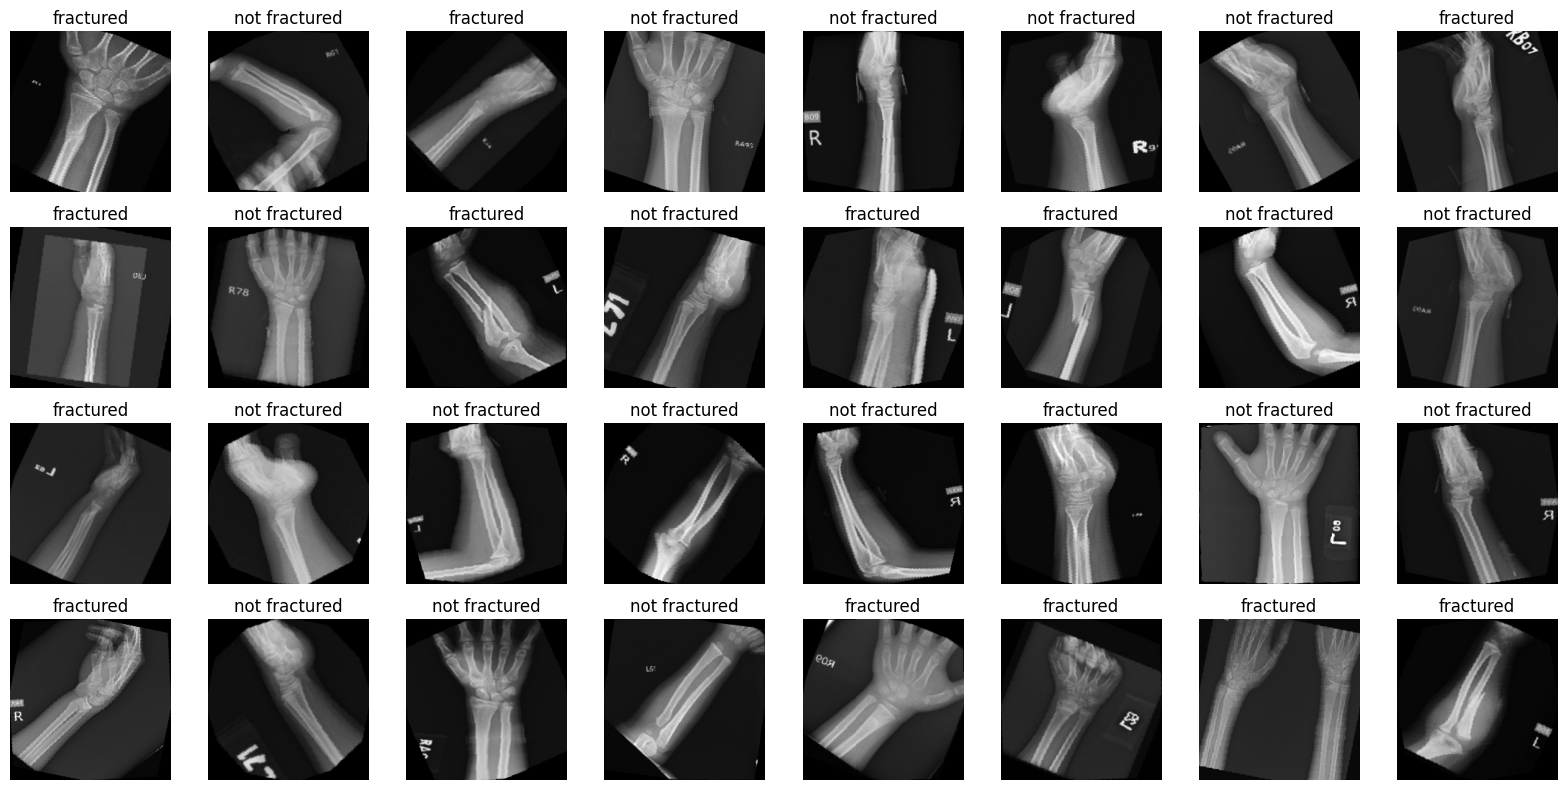

In [ ]:
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(min(len(xb), 32)): # Display up to 32 images
    ax = axes[i]
    img = xb[i].permute(1, 2, 0).cpu().numpy() # Convert from C, H, W to H, W, C
    # Denormalize for display if necessary (for base model, already in [0,1])
    ax.imshow(img)
    ax.set_title(class_names[yb[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6) Train baseline CNN

Default **5 epochs** / **lr=1e-3** — increase epochs for stronger convergence if you have a GPU.


In [13]:
EPOCHS_BASE = 5
LR_BASE = 1e-3

torch.manual_seed(RANDOM_SEED)
baseline = SmallCNN()
baseline, hist_base = train_model(
    baseline, loaders_base, epochs=EPOCHS_BASE, lr=LR_BASE, label="baseline"
)
plot_history(hist_base, "Baseline CNN")
metrics_base = evaluate_split(baseline, loaders_base["test"], "Baseline — test")

KeyboardInterrupt: 

## 7) Train ResNet50 (transfer learning)

Lower learning rate (1e-4) for fine-tuning pretrained weights. Uses the ImageNet-normalized loaders.

In [ ]:
EPOCHS_RN = 5
LR_RN = 1e-4

torch.manual_seed(RANDOM_SEED)
resnet = build_resnet50_fracture()
resnet, hist_rn = train_model(
    resnet, loaders_rn, epochs=EPOCHS_RN, lr=LR_RN, label="resnet50"
)
plot_history(hist_rn, "ResNet50 fine-tuned")
metrics_rn = evaluate_split(resnet, loaders_rn["test"], "ResNet50 — test")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 60.7MB/s]


[resnet50] epoch 1/5  train_loss=0.1863  val_loss=0.0411  val_acc=0.9857


## 8) Side-by-side comparison & ROC curves

We compare overall accuracy, **ROC-AUC**, and **recall for class0 (`fractured`)** — proxy for sensitivity to injuries.

In [12]:
rows = []
for name, m in [("Baseline CNN", metrics_base), ("ResNet50", metrics_rn)]:
    rep = classification_report(
        m["y_true"], m["y_pred"], target_names=class_names, output_dict=True, zero_division=0
    )
    rows.append(
        {
            "model": name,
            "test_acc": m["acc"],
            "test_auc": m["auc"],
            "recall_fractured": rep[class_names[0]]["recall"],
            "recall_not_fractured": rep[class_names[1]]["recall"],
        }
    )

summary_df = pd.DataFrame(rows)
display(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, m, title in zip(
    axes,
    [metrics_base, metrics_rn],
    ["Baseline — confusion (test)", "ResNet50 — confusion (test)"],
):
    cm = confusion_matrix(m["y_true"], m["y_pred"])
    ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_names, rotation=20, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
for m, label, color in [
    (metrics_base, "Baseline", "#4C72B0"),
    (metrics_rn, "ResNet50", "#DD8452"),
]:
    # y_true==1 means "not fractured"; ROC uses positive label1 by default
    y_bin = (m["y_true"] == 0).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, m["y_score"])
    plt.plot(fpr, tpr, label=f"{label} (AUC={m['auc']:.3f})", color=color)
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC — injury positive = fractured (score = softmax prob of class 0)")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'metrics_base' is not defined

### Visualize Raw Images

Let's start by looking at a few raw images directly from the loaded dataset (`full_train`). This helps understand the initial input to our models. You can run this cell after the dataset is loaded (e.g., after cell `oR0EyV5jFOYz`).

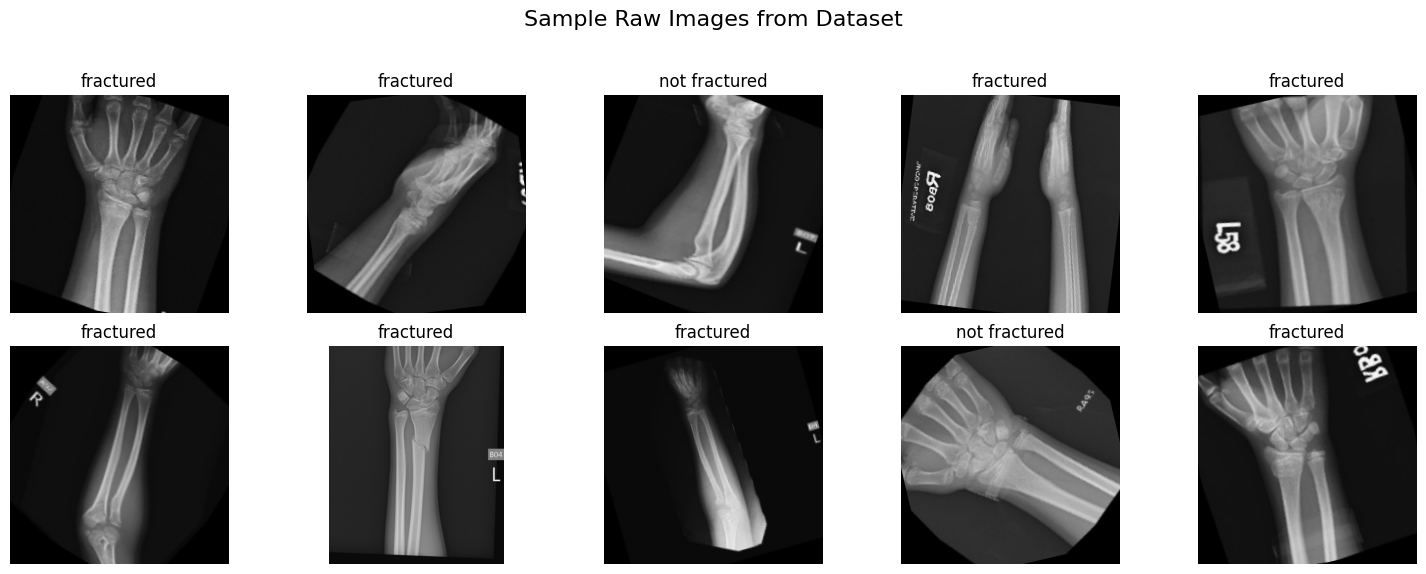

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    ax = axes[i]
    # Get a random image from the full dataset
    rand_idx = random.randint(0, len(full_train) - 1)
    ex = full_train[rand_idx]
    img = pil_rgb(ex)
    label = class_names[ex['label']]

    ax.imshow(img)
    ax.set_title(label)
    ax.axis('off')

plt.suptitle('Sample Raw Images from Dataset', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Visualize Augmented Image (Baseline Model)

Here's an example of an image after applying the training transformations for the baseline CNN. Notice the rotation, horizontal flip, or color jitter if applied. You can run this cell after `tf_train_base` is defined (e.g., within or after cell `yIXouo0BIGDq`).

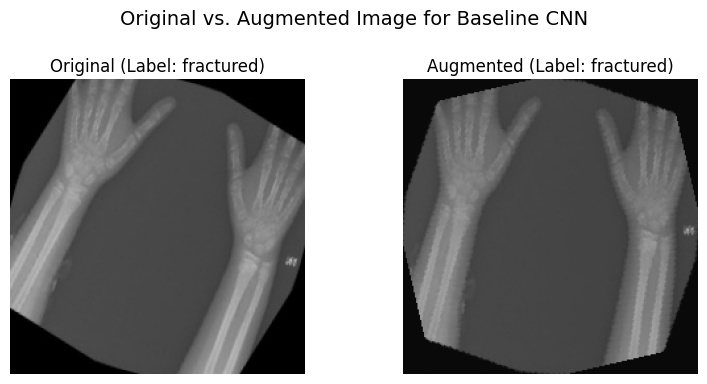

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Get a random image from the training set indices
rand_idx_train = int(random.choice(train_idx)) # Cast to int
ex_original = full_train[rand_idx_train]
original_img_pil = pil_rgb(ex_original)
original_label = class_names[ex_original['label']]

# Apply baseline training transforms (with augmentation)
augmented_img_tensor = tf_train_base(original_img_pil)
augmented_img_display = augmented_img_tensor.permute(1, 2, 0).cpu().numpy()

axes[0].imshow(original_img_pil)
axes[0].set_title(f'Original (Label: {original_label})')
axes[0].axis('off')

axes[1].imshow(augmented_img_display)
axes[1].set_title(f'Augmented (Label: {original_label})')
axes[1].axis('off')

plt.suptitle('Original vs. Augmented Image for Baseline CNN', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Visualize ImageNet Normalized Image (ResNet Model)

This shows an image after applying the evaluation transformations for ResNet, which includes ImageNet mean/std normalization. Note that the colors might appear unusual due to this normalization, as it's designed for the ResNet model's specific training, not for human visual interpretation. You can run this cell after `tf_eval_rn` is defined (e.g., within or after cell `yIXouo0BIGDq`).

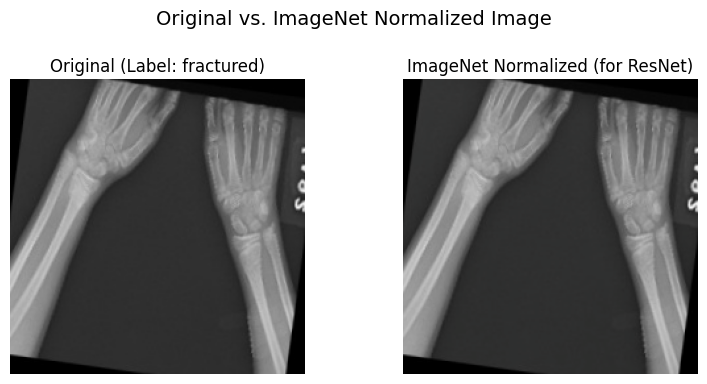

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Get a random image from the validation set indices
rand_idx_val = int(random.choice(val_idx)) # Cast to int
ex_original = full_train[rand_idx_val]
original_img_pil = pil_rgb(ex_original)
original_label = class_names[ex_original['label']]

# Apply ResNet evaluation transforms (includes ImageNet normalization)
normalized_img_tensor = tf_eval_rn(original_img_pil)

# Denormalize for display (reverse of ImageNet normalization)
display_img_tensor = normalized_img_tensor.clone()
for t, m, s in zip(display_img_tensor, IMAGENET_MEAN, IMAGENET_STD):
    t.mul_(s).add_(m)
display_img_array = display_img_tensor.permute(1, 2, 0).cpu().numpy()
display_img_array = np.clip(display_img_array, 0, 1) # Clip to [0,1] range

axes[0].imshow(original_img_pil)
axes[0].set_title(f'Original (Label: {original_label})')
axes[0].axis('off')

axes[1].imshow(display_img_array)
axes[1].set_title(f'ImageNet Normalized (for ResNet)')
axes[1].axis('off')

plt.suptitle('Original vs. ImageNet Normalized Image', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Visualize a Sample Batch from ResNet DataLoader

Similar to the baseline visualization, let's look at a batch of images that will be fed into the ResNet model during training. These images have undergone augmentation and ImageNet normalization. You can run this cell after `loaders_rn` is defined (e.g., within or after cell `yIXouo0BIGDq`).

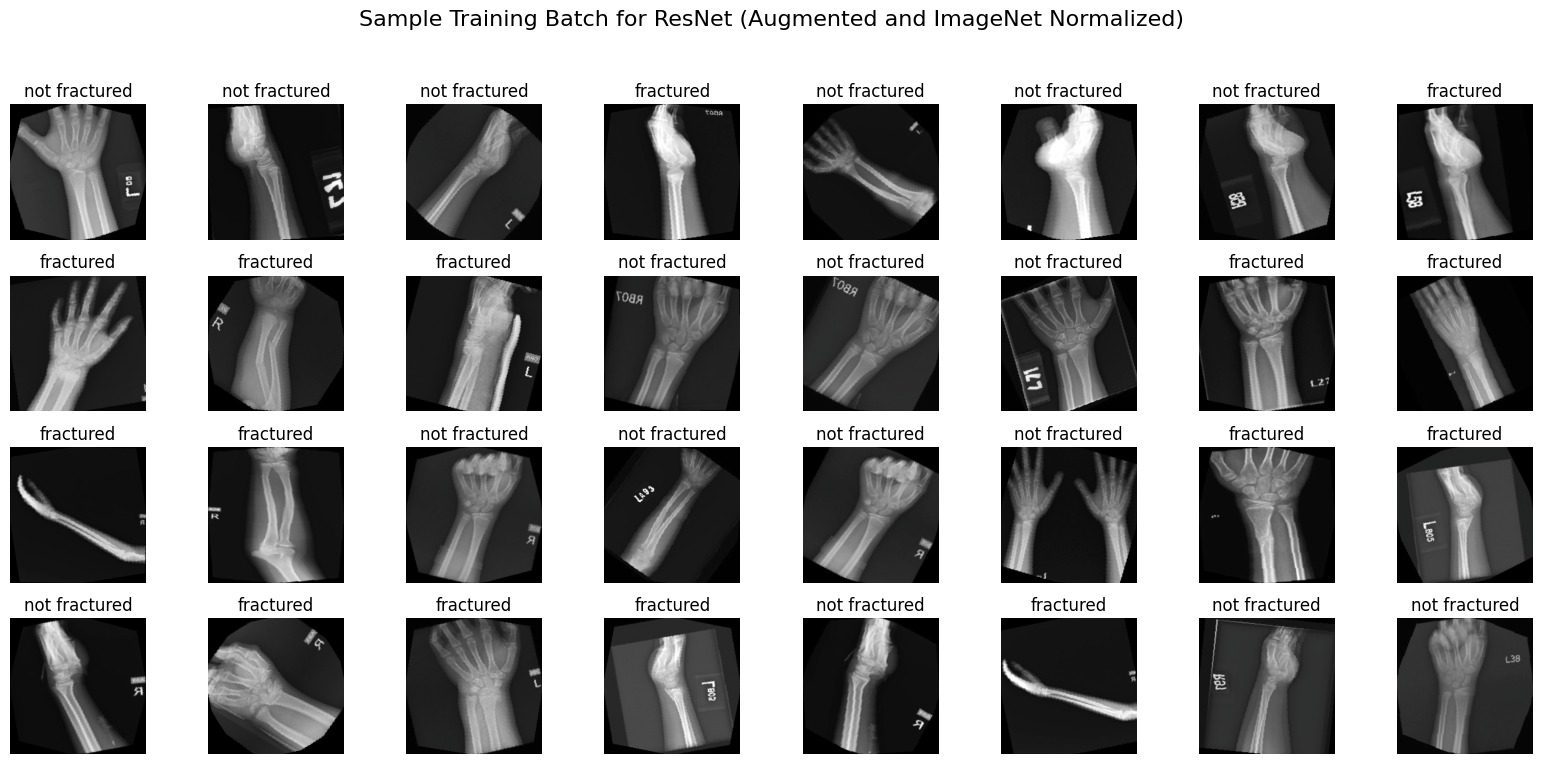

In [17]:
xb_rn, yb_rn = next(iter(loaders_rn["train"]))

fig_rn, axes_rn = plt.subplots(4, 8, figsize=(16, 8))
axes_rn = axes_rn.flatten()

for i in range(min(len(xb_rn), 32)): # Display up to 32 images
    ax = axes_rn[i]
    img_tensor = xb_rn[i]

    # Denormalize for display (reverse of ImageNet normalization)
    display_img_tensor = img_tensor.clone()
    for t, m, s in zip(display_img_tensor, IMAGENET_MEAN, IMAGENET_STD):
        t.mul_(s).add_(m)
    img_array = display_img_tensor.permute(1, 2, 0).cpu().numpy()
    img_array = np.clip(img_array, 0, 1)

    ax.imshow(img_array)
    ax.set_title(class_names[yb_rn[i].item()])
    ax.axis("off")

plt.suptitle('Sample Training Batch for ResNet (Augmented and ImageNet Normalized)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Visualize the Image from the Demo Prediction

Finally, let's visualize the actual image that was used for the `injury_recommendation` demo. This allows us to see what the model was looking at when making its prediction. You can run this cell after the `injury_recommendation` function is called and `metrics_rn` is populated (e.g., after cell `NJg5s4yyiTon`).

In [18]:
if 'metrics_rn' in locals() and len(metrics_rn['y_pred']) > 0:
    # Get the index of the image within the test_idx array that corresponds to the first prediction
    # The metrics_rn arrays are built from the test_loader, which is not shuffled.
    # So, metrics_rn[0] corresponds to the image at test_idx[0].
    original_dataset_index = test_idx[0]
    demo_image_data = full_train[original_dataset_index]
    demo_image_pil = pil_rgb(demo_image_data)
    true_label = class_names[demo_image_data['label']]
    predicted_label = class_names[metrics_rn['y_pred'][0]]

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))

    # Display the image
    ax.imshow(demo_image_pil)
    ax.set_title(f'Demo Image\nTrue: {true_label}, Predicted: {predicted_label}')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Metrics for ResNet not available or empty. Please ensure ResNet training and evaluation were completed.")

Metrics for ResNet not available or empty. Please ensure ResNet training and evaluation were completed.


**ROC setup:** the injury-positive label is **fractured** (class index **0**). `y_score` is **P(fractured)** from the softmax output.

---

## 9) Progress 2 summary

- Built **stratified** splits and **DataLoaders** with **train-time augmentation**.
- Trained a **baseline CNN** and a **ResNet50** model with **ImageNet** initialization.
- Reported **test accuracy**, **confusion matrices**, **per-class precision/recall/F1**, and **ROC-AUC**.
.


In [ ]:
def injury_recommendation(pred_class_name: str) -> str:
    """Map model output to high-level non-clinical guidance text (prototype)."""
    if pred_class_name.lower().startswith("frac"):
        return (
            "Predicted: fracture. In a real system this would flag urgent follow-up: "
            "immobilization and specialist/surgical evaluation per local protocols."
        )
    return (
        "Predicted: no fracture. If symptoms persist, the proposal suggests clinical "
        "reassessment and graded return-to-play considerations — not a substitute for a radiologist."
    )


demo_pred = class_names[metrics_rn["y_pred"][0]]
print(injury_recommendation(demo_pred))